# Deeper Player Scouting

This notebook explores the drivers behind FPL performance: recent form, expected involvement, efficiency, minutes, ownership, and upcoming fixtures. It fetches its own data so it can run independently of `Fantasy_Scout.ipynb`.

Use the sections in order. The shortlist is a comparison aid, not an automatic transfer recommendation.

## 1. Data Setup

Retrieve player, team, and fixture data directly from the FPL API. The fixture table is initialized with a stable schema so later sections still work when no fixtures are available in the selected window.

In [1]:
import pandas as pd
import requests

BASE_URL = "https://fantasy.premierleague.com/api"
MIN_MINUTES = 90
FIXTURE_WINDOW = 5
REQUEST_TIMEOUT = 20


def fetch_json(url: str, timeout: int = REQUEST_TIMEOUT):
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()


bootstrap = fetch_json(f"{BASE_URL}/bootstrap-static/")
fixtures_payload = fetch_json(f"{BASE_URL}/fixtures/")

team_map = {team["id"]: team["name"] for team in bootstrap.get("teams", [])}
position_map = {
    position["id"]: position.get("singular_name_short", position.get("singular_name"))
    for position in bootstrap.get("element_types", [])
}

players_df = pd.DataFrame(bootstrap.get("elements", []))
players_df = players_df.rename(columns={
    "id": "player_id",
    "web_name": "name",
    "element_type": "position_id",
    "now_cost": "price_tenths",
    "selected_by_percent": "ownership_pct",
})

players_df["team"] = players_df["team"].map(team_map)
players_df["position"] = players_df["position_id"].map(position_map)
players_df["price"] = pd.to_numeric(players_df["price_tenths"], errors="coerce") / 10

numeric_columns = [
    "total_points", "form", "expected_goals", "expected_assists", "ict_index",
    "minutes", "goals_scored", "assists", "clean_sheets", "saves",
    "goals_conceded", "bonus", "ownership_pct",
]
for column in numeric_columns:
    if column not in players_df:
        players_df[column] = 0
    players_df[column] = pd.to_numeric(players_df[column], errors="coerce").fillna(0)

players_df = players_df.rename(columns={
    "expected_goals": "xg",
    "expected_assists": "xa",
})

current_event = bootstrap.get("current_event")
if current_event is None:
    current_event = next(
        (event["id"] for event in bootstrap.get("events", []) if event.get("is_next")),
        1,
    )
current_event = int(current_event)

upcoming_fixtures = [
    fixture for fixture in fixtures_payload
    if fixture.get("event") is not None
    and fixture.get("finished") is False
    and current_event <= int(fixture["event"]) < current_event + FIXTURE_WINDOW
]

fixture_rows = []
for fixture in upcoming_fixtures:
    fixture_rows.extend([
        {
            "event": fixture["event"],
            "team_id": fixture["team_h"],
            "team_name": team_map.get(fixture["team_h"]),
            "opponent": team_map.get(fixture["team_a"]),
            "is_home": True,
            "difficulty": fixture.get("team_h_difficulty"),
        },
        {
            "event": fixture["event"],
            "team_id": fixture["team_a"],
            "team_name": team_map.get(fixture["team_a"]),
            "opponent": team_map.get(fixture["team_h"]),
            "is_home": False,
            "difficulty": fixture.get("team_a_difficulty"),
        },
    ])

fixture_columns = ["event", "team_id", "team_name", "opponent", "is_home", "difficulty"]
fixtures_df = pd.DataFrame(fixture_rows, columns=fixture_columns)
if not fixtures_df.empty:
    fixtures_df["difficulty"] = pd.to_numeric(fixtures_df["difficulty"], errors="coerce")

print(f"Loaded {len(players_df)} players and {len(fixtures_df)} team-fixture rows.")
print(f"Fixture window: {FIXTURE_WINDOW} gameweeks; minimum minutes: {MIN_MINUTES}.")

Loaded 667 players and 100 team-fixture rows.
Fixture window: 5 gameweeks; minimum minutes: 90.


## 2. Shared Player Metrics

Build the common comparison fields once. Per-90 values help normalize playing time; they should be read alongside minutes because very small samples can look unusually strong.

In [2]:
analysis_df = players_df.copy()
minutes_factor = analysis_df["minutes"].div(90).replace(0, pd.NA)
analysis_df["points_per_90"] = analysis_df["total_points"].div(minutes_factor)
analysis_df["xg_per_90"] = analysis_df["xg"].div(minutes_factor)
analysis_df["xa_per_90"] = analysis_df["xa"].div(minutes_factor)
analysis_df["points_per_price"] = analysis_df["total_points"].div(
    analysis_df["price"].replace(0, pd.NA)
)
analysis_df["attacking_involvement"] = analysis_df["xg"] + analysis_df["xa"]
analysis_df["goal_difference"] = analysis_df["goals_scored"] - analysis_df["xg"]
analysis_df["assist_difference"] = analysis_df["assists"] - analysis_df["xa"]
analysis_df["goal_threat"] = analysis_df["goals_scored"] + analysis_df["xg"]
analysis_df["attacking_returns"] = analysis_df["goals_scored"] + analysis_df["assists"]

eligible_df = analysis_df[analysis_df["minutes"] >= MIN_MINUTES].copy()
if "status" in eligible_df.columns:
    available_df = eligible_df[eligible_df["status"] == "a"].copy()
else:
    available_df = eligible_df.copy()

print(f"Players meeting the minutes threshold: {len(eligible_df)}")
print(f"Available players in that group: {len(available_df)}")

Players meeting the minutes threshold: 296
Available players in that group: 258


## 3. Recent Form and Reliability

### 3.1 Form, minutes, and points

The active-player view puts recent form beside minutes and points-per-90 to make short-sample performance easier to judge.

In [3]:
form_view = available_df.sort_values(
    ["form", "points_per_90", "minutes"],
    ascending=False,
)

form_columns = [
    "name", "position", "team", "price", "form", "minutes",
    "total_points", "points_per_90", "ownership_pct",
]
form_view[form_columns].head(20)

,name,position,team,price,form,minutes,total_points,points_per_90,ownership_pct
403,Bogle,DEF,Leeds,4.6,11.3,365,42,10.356164,7.2
136,Groß,MID,Brighton,5.8,10.7,450,47,9.4,28.8
105,Schade,MID,Brentford,6.2,8.7,447,39,7.852349,11.5
151,Vuskovic,DEF,Brighton,5.0,8.7,437,32,6.590389,3.6
272,Tarkowski,DEF,Everton,6.1,8.3,450,43,8.6,16.5
430,A.Becker,GKP,Liverpool,5.5,8.3,450,27,5.4,4.1
491,Haaland,FWD,Man City,15.6,8.0,450,39,7.8,73.8
474,Gvardiol,DEF,Man City,5.7,7.7,434,37,7.672811,26.8
544,Barnes,MID,Newcastle,6.1,7.7,450,28,5.6,5.7
237,Mitchell,DEF,Crystal Palace,4.5,7.7,419,24,5.155131,6.0


### 3.2 Actual returns and expected involvement

Compare goals and assists with xG and xA. Positive differences describe returns above the current expected totals; they are descriptive, not forecasts.

In [4]:
expected_view = eligible_df[
    eligible_df["position"].isin(["MID", "FWD"])
].sort_values("attacking_involvement", ascending=False)

expected_columns = [
    "name", "position", "team", "price", "goals_scored", "xg",
    "assists", "xa", "goal_difference", "assist_difference",
    "attacking_involvement",
]
expected_view[expected_columns].head(20)

,name,position,team,price,goals_scored,xg,assists,xa,goal_difference,assist_difference,attacking_involvement
491,Haaland,FWD,Man City,15.6,5,4.42,0,0.53,0.58,-0.53,4.95
11,Saka,MID,Arsenal,9.5,3,3.22,0,0.98,-0.22,-0.98,4.20
517,B.Fernandes,MID,Man Utd,11.9,3,2.56,1,1.32,0.44,-0.32,3.88
518,Mbeumo,MID,Man Utd,7.9,2,3.07,1,0.80,-1.07,0.20,3.87
289,Barry,FWD,Everton,5.7,2,3.50,0,0.15,-1.50,-0.15,3.65
459,Isak,FWD,Liverpool,9.1,4,3.54,0,0.08,0.46,-0.08,3.62
651,E.Le Fée,MID,Sunderland,5.7,1,2.06,1,1.34,-1.06,-0.34,3.40
115,Thiago,FWD,Brentford,7.8,1,3.13,0,0.16,-2.13,-0.16,3.29
418,Calvert-Lewin,FWD,Leeds,6.0,2,3.00,1,0.08,-1.00,0.92,3.08
661,Brobbey,FWD,Sunderland,5.7,3,2.94,0,0.11,0.06,-0.11,3.05


### 3.3 Per-90 output and value

These rates normalize points and expected output by minutes. `points_per_price` is total points divided by current price in millions.

In [5]:
per90_view = eligible_df.sort_values("points_per_90", ascending=False)
per90_columns = [
    "name", "position", "team", "price", "minutes", "points_per_90",
    "xg_per_90", "xa_per_90", "points_per_price",
]
per90_view[per90_columns].head(20)

,name,position,team,price,minutes,points_per_90,xg_per_90,xa_per_90,points_per_price
49,Manzambi,MID,Aston Villa,5.9,98,12.857143,0.404082,0.220408,2.372881
662,Isidor,FWD,Sunderland,5.5,117,11.538462,1.146154,0.007692,2.727273
290,Maitland-Niles,DEF,Everton,4.5,177,10.677966,0.030508,0.127119,4.666667
403,Bogle,DEF,Leeds,4.6,365,10.356164,0.340274,0.019726,9.130435
482,Cherki,MID,Man City,7.8,302,10.13245,0.21457,0.45894,4.358974
157,Andrés,MID,Brighton,5.5,109,9.908257,0.429358,0.099083,2.181818
136,Groß,MID,Brighton,5.8,450,9.4,0.354,0.172,8.103448
355,Mendy,DEF,Hull City,4.1,249,9.036145,0.115663,0.0,6.097561
272,Tarkowski,DEF,Everton,6.1,450,8.6,0.036,0.008,7.049180
184,João Pedro,FWD,Chelsea,7.7,360,8.25,0.5425,0.0475,4.285714


## 4. Fixture Suitability

Summarize the next five gameweeks by team, then attach the schedule to each player's team. If there are no unplayed fixtures in the selected window, the notebook reports that clearly and continues.

In [6]:
fixture_summary_columns = [
    "team_name", "fixtures", "average_difficulty", "home_fixtures",
]
if fixtures_df.empty:
    fixture_summary = pd.DataFrame(columns=fixture_summary_columns)
    print("No upcoming fixtures found in the selected window.")
else:
    fixture_summary = (
        fixtures_df.groupby("team_name", as_index=False)
        .agg(
            fixtures=("event", "count"),
            average_difficulty=("difficulty", "mean"),
            home_fixtures=("is_home", "sum"),
        )
        .sort_values(["average_difficulty", "fixtures"])
    )
    display(fixture_summary)

fixture_lookup = fixture_summary.rename(columns={"team_name": "team"})
player_fixtures = available_df.merge(fixture_lookup, on="team", how="left")
player_fixtures["fixtures"] = player_fixtures["fixtures"].fillna(0).astype(int)
player_fixtures["home_fixtures"] = player_fixtures["home_fixtures"].fillna(0).astype(int)

player_fixture_columns = [
    "name", "position", "team", "price", "minutes", "form", "fixtures",
    "average_difficulty", "home_fixtures",
]
player_fixtures[player_fixture_columns].sort_values(
    ["average_difficulty", "form"], ascending=[True, False], na_position="last"
).head(20)

,team_name,fixtures,average_difficulty,home_fixtures
9,Fulham,5,2.4,2
6,Coventry City,5,2.8,3
16,Newcastle,5,2.8,2
0,Arsenal,5,3.0,3
5,Chelsea,5,3.0,3
11,Ipswich Town,5,3.0,3
14,Man City,5,3.0,2
15,Man Utd,5,3.0,3
18,Spurs,5,3.0,2
19,Sunderland,5,3.0,3


,name,position,team,price,minutes,form,fixtures,average_difficulty,home_fixtures
123,King,MID,Fulham,5.5,425,5.0,5,2.4,2
114,Leno,GKP,Fulham,4.5,450,4.3,5,2.4,2
118,Bassey,DEF,Fulham,4.5,450,4.3,5,2.4,2
127,Affengruber,DEF,Fulham,4.5,180,4.0,5,2.4,2
126,Charles,MID,Fulham,5.0,303,3.7,5,2.4,2
120,Iwobi,MID,Fulham,5.4,408,3.3,5,2.4,2
116,Robinson,DEF,Fulham,4.5,429,3.0,5,2.4,2
125,Palacios,MID,Fulham,5.4,226,3.0,5,2.4,2
119,Castagne,DEF,Fulham,4.5,408,2.7,5,2.4,2
121,Bobb,MID,Fulham,5.5,343,2.7,5,2.4,2


## 5. Scouting Shortlist

The balanced score ranks players on points per 90, points per price, form, and expected attacking involvement. It is intended to surface candidates for review, not to make transfer decisions automatically.

In [7]:
scouting_view = available_df.copy()
scouting_metrics = [
    "points_per_90", "points_per_price", "form", "attacking_involvement",
]
for metric in scouting_metrics:
    scouting_view[f"{metric}_rank"] = scouting_view[metric].rank(pct=True).fillna(0)

scouting_view["scouting_score"] = scouting_view[
    [f"{metric}_rank" for metric in scouting_metrics]
].mean(axis=1)

shortlist = scouting_view.sort_values(
    ["scouting_score", "minutes"], ascending=False
)
shortlist_columns = [
    "name", "position", "team", "price", "form", "minutes", "total_points",
    "points_per_90", "points_per_price", "attacking_involvement",
    "ownership_pct", "scouting_score",
]
shortlist[shortlist_columns].head(20)

,name,position,team,price,form,minutes,total_points,points_per_90,points_per_price,attacking_involvement,ownership_pct,scouting_score
136,Groß,MID,Brighton,5.8,10.7,450,47,9.4,8.103448,2.63,28.8,0.981589
403,Bogle,DEF,Leeds,4.6,11.3,365,42,10.356164,9.130435,1.46,7.2,0.963663
127,De Cuyper,DEF,Brighton,5.0,7.0,423,38,8.085106,7.600000,2.22,27.7,0.957849
105,Schade,MID,Brentford,6.2,8.7,447,39,7.852349,6.290323,1.84,11.5,0.954942
76,Tavernier,MID,Bournemouth,6.1,6.7,424,31,6.580189,5.081967,2.62,6.8,0.921996
148,Kostoulas,FWD,Brighton,5.6,7.3,353,28,7.13881,5.000000,1.41,4.1,0.913275
334,Belloumi,MID,Hull City,5.1,7.3,394,31,7.081218,6.078431,1.15,5.1,0.907461
474,Gvardiol,DEF,Man City,5.7,7.7,434,37,7.672811,6.491228,0.96,26.8,0.902616
381,Emersonn,FWD,Ipswich Town,5.5,5.3,317,26,7.381703,4.727273,1.73,3.5,0.890019
11,Saka,MID,Arsenal,9.5,5.8,416,32,6.923077,3.368421,4.20,13.7,0.883721


## 6. Position-Based Assessments

Each position uses a compact set of role-relevant statistics. These views include players meeting the minutes threshold, whether or not their current availability status is active.

### 6.1 Goalkeepers

In [8]:
keepers = eligible_df[eligible_df["position"] == "GKP"].copy()
keeper_minutes = keepers["minutes"].div(90).replace(0, pd.NA)
keepers["saves_per_90"] = keepers["saves"].div(keeper_minutes)
keepers["attacking_contribution"] = keepers["goals_scored"] + keepers["assists"]
keepers = keepers.sort_values(
    ["clean_sheets", "saves_per_90", "points_per_90"], ascending=False
)

keeper_columns = [
    "name", "team", "price", "minutes", "total_points", "clean_sheets",
    "saves", "saves_per_90", "goals_conceded", "attacking_contribution",
    "points_per_90", "ownership_pct",
]
keepers[keeper_columns].head(15)

,name,team,price,minutes,total_points,clean_sheets,saves,saves_per_90,goals_conceded,attacking_contribution,points_per_90,ownership_pct
351,Tzolakis,Hull City,4.7,450,34,3,17,3.40,4,0,6.8,12.8
269,Pickford,Everton,5.5,450,25,3,15,3.00,3,0,5.0,9.1
430,A.Becker,Liverpool,5.5,450,27,3,14,2.80,4,0,5.4,4.1
123,Verbruggen,Brighton,4.5,450,23,3,12,2.40,5,0,4.6,21.6
0,Raya,Arsenal,6.1,450,30,3,9,1.80,4,0,6.0,42.3
422,Trafford,Leeds,5.0,450,28,2,20,4.00,3,0,5.6,5.5
94,Kelleher,Brentford,5.0,450,20,2,17,3.40,4,0,4.0,6.1
468,Donnarumma,Man City,5.5,450,19,2,14,2.80,5,0,3.8,7.6
604,Kinsky,Spurs,4.5,450,18,2,12,2.40,8,0,3.6,17.3
558,Horníček,Newcastle,5.0,450,14,1,19,3.80,9,0,2.8,1.5


### 6.2 Defenders

In [9]:
defenders = eligible_df[eligible_df["position"] == "DEF"].copy()
defenders["defender_output"] = (
    defenders["clean_sheets"]
    + defenders["goals_scored"]
    + defenders["assists"]
    + defenders["bonus"]
)
defenders = defenders.sort_values(
    ["defender_output", "points_per_90", "minutes"], ascending=False
)

defender_columns = [
    "name", "team", "price", "minutes", "total_points", "clean_sheets",
    "goals_scored", "assists", "bonus", "defender_output",
    "points_per_90", "ownership_pct",
]
defenders[defender_columns].head(20)

,name,team,price,minutes,total_points,clean_sheets,goals_scored,assists,bonus,defender_output,points_per_90,ownership_pct
403,Bogle,Leeds,4.6,365,42,4,2,0,6,12,10.356164,7.2
272,Tarkowski,Everton,6.1,450,43,3,1,1,7,12,8.6,16.5
127,De Cuyper,Brighton,5.0,423,38,3,1,3,5,12,8.085106,27.7
474,Gvardiol,Man City,5.7,434,37,2,1,3,6,12,7.672811,26.8
541,Hall,Newcastle,5.3,449,31,1,1,1,6,9,6.213808,17.3
471,Guéhi,Man City,6.0,450,30,2,1,1,4,8,6.0,18.2
7,Calafiori,Arsenal,5.8,416,29,3,0,2,2,7,6.274038,50.5
151,Vuskovic,Brighton,5.0,437,32,3,1,0,2,6,6.590389,3.6
9,White,Arsenal,5.5,315,21,2,0,1,3,6,6.0,4.9
327,Ajayi,Hull City,4.2,423,27,3,1,0,2,6,5.744681,14.0


### 6.3 Midfielders

In [10]:
midfielders = eligible_df[eligible_df["position"] == "MID"].copy()
midfielders = midfielders.sort_values(
    ["attacking_involvement", "attacking_returns", "points_per_90"],
    ascending=False,
)

midfielder_columns = [
    "name", "team", "price", "minutes", "total_points", "form",
    "goals_scored", "assists", "xg", "xa", "attacking_involvement",
    "points_per_90", "ownership_pct",
]
midfielders[midfielder_columns].head(20)

,name,team,price,minutes,total_points,form,goals_scored,assists,xg,xa,attacking_involvement,points_per_90,ownership_pct
11,Saka,Arsenal,9.5,416,32,5.8,3,0,3.22,0.98,4.20,6.923077,13.7
517,B.Fernandes,Man Utd,11.9,450,31,2.0,3,1,2.56,1.32,3.88,6.2,38.5
518,Mbeumo,Man Utd,7.9,450,25,4.0,2,1,3.07,0.80,3.87,5.0,20.6
651,E.Le Fée,Sunderland,5.7,438,18,4.3,1,1,2.06,1.34,3.40,3.69863,3.4
582,Gibbs-White,Nott'm Forest,8.0,450,28,4.3,1,2,1.56,1.42,2.98,5.6,15.7
161,Rogers,Chelsea,7.7,437,29,5.3,3,1,1.72,1.23,2.95,5.97254,40.5
136,Groß,Brighton,5.8,450,47,10.7,3,4,1.77,0.86,2.63,9.4,28.8
76,Tavernier,Bournemouth,6.1,424,31,6.7,3,0,1.70,0.92,2.62,6.580189,6.8
481,Foden,Man City,6.9,217,9,-0.3,0,2,1.61,0.88,2.49,3.732719,1.8
14,Ødegaard,Arsenal,6.8,377,29,4.5,2,0,1.08,1.32,2.40,6.923077,19.8


### 6.4 Forwards

In [11]:
attackers = eligible_df[eligible_df["position"] == "FWD"].copy()
attackers = attackers.sort_values(
    ["goal_threat", "attacking_returns", "points_per_90"], ascending=False
)

attacker_columns = [
    "name", "team", "price", "minutes", "total_points", "form",
    "goals_scored", "assists", "xg", "goal_threat", "attacking_returns",
    "points_per_90", "ownership_pct",
]
attackers[attacker_columns].head(20)

,name,team,price,minutes,total_points,form,goals_scored,assists,xg,goal_threat,attacking_returns,points_per_90,ownership_pct
491,Haaland,Man City,15.6,450,39,8.0,5,0,4.42,9.42,5,7.8,73.8
459,Isak,Liverpool,9.1,413,33,7.7,4,0,3.54,7.54,4,7.191283,22.4
661,Brobbey,Sunderland,5.7,399,24,6.7,3,0,2.94,5.94,3,5.413534,7.0
289,Barry,Everton,5.7,417,20,3.3,2,0,3.50,5.50,2,4.316547,8.3
184,João Pedro,Chelsea,7.7,360,33,4.3,3,3,2.17,5.17,6,8.25,65.2
418,Calvert-Lewin,Leeds,6.0,419,22,4.3,2,1,3.00,5.00,3,4.725537,24.8
115,Thiago,Brentford,7.8,442,10,2.7,1,0,3.13,4.13,1,2.036199,9.1
24,Havertz,Arsenal,7.6,437,19,3.2,2,0,1.67,3.67,2,3.913043,8.3
381,Emersonn,Ipswich Town,5.5,317,26,5.3,2,1,1.61,3.61,3,7.381703,3.5
148,Kostoulas,Brighton,5.6,353,28,7.3,2,3,1.35,3.35,5,7.13881,4.1


## 7. Scouting Visualizations

### 7.1 Points versus price

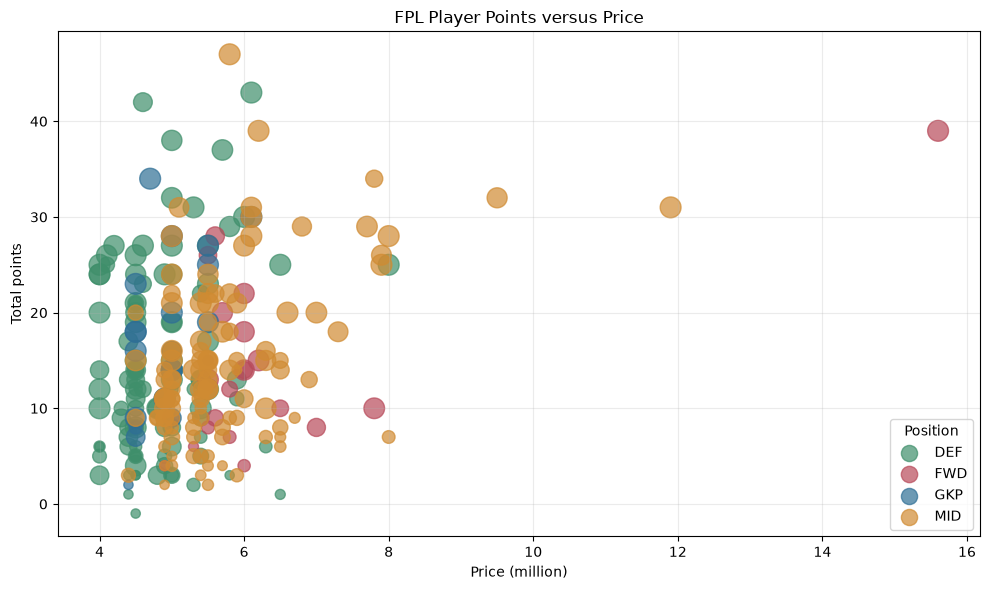

In [12]:
import matplotlib.pyplot as plt

position_colors = {
    "GKP": "#2f6f95",
    "DEF": "#3f8f6b",
    "MID": "#d08b32",
    "FWD": "#b84a5a",
}

plot_data = available_df.copy()
fig, ax = plt.subplots(figsize=(10, 6))
for position, group in plot_data.groupby("position"):
    ax.scatter(
        group["price"],
        group["total_points"],
        s=group["minutes"].clip(lower=30) / 2,
        alpha=0.7,
        label=position,
        color=position_colors.get(position, "#666666"),
    )

ax.set_title("FPL Player Points versus Price")
ax.set_xlabel("Price (million)")
ax.set_ylabel("Total points")
ax.legend(title="Position")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 7.2 Expected attacking involvement

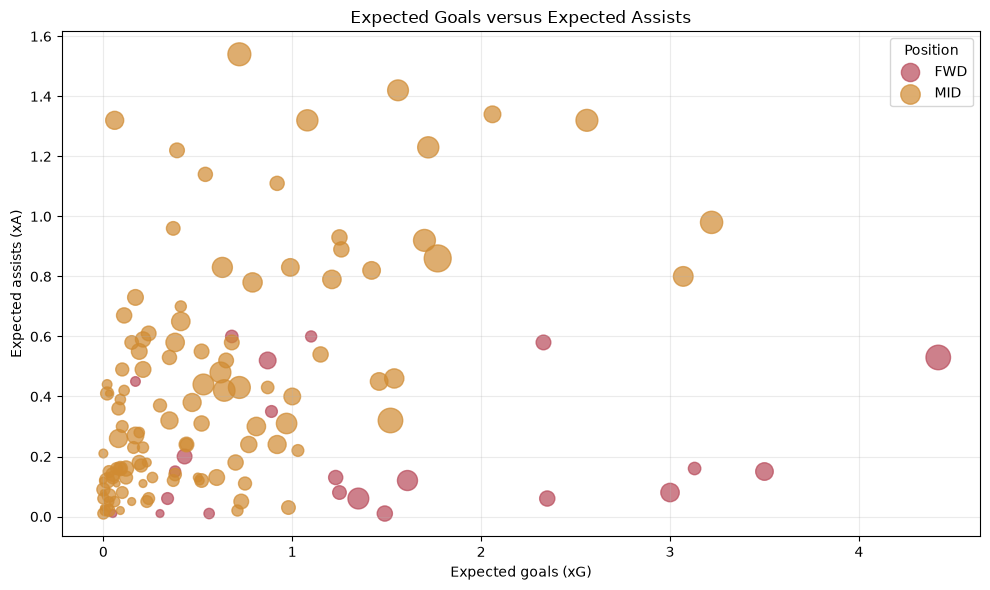

In [13]:
attacking_plot = available_df[
    available_df["position"].isin(["MID", "FWD"])
].copy()
fig, ax = plt.subplots(figsize=(10, 6))
for position, group in attacking_plot.groupby("position"):
    ax.scatter(
        group["xg"],
        group["xa"],
        s=group["total_points"].clip(lower=1) * 8,
        alpha=0.7,
        label=position,
        color=position_colors.get(position, "#666666"),
    )

ax.set_title("Expected Goals versus Expected Assists")
ax.set_xlabel("Expected goals (xG)")
ax.set_ylabel("Expected assists (xA)")
ax.legend(title="Position")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 7.3 Shortlist value and ownership

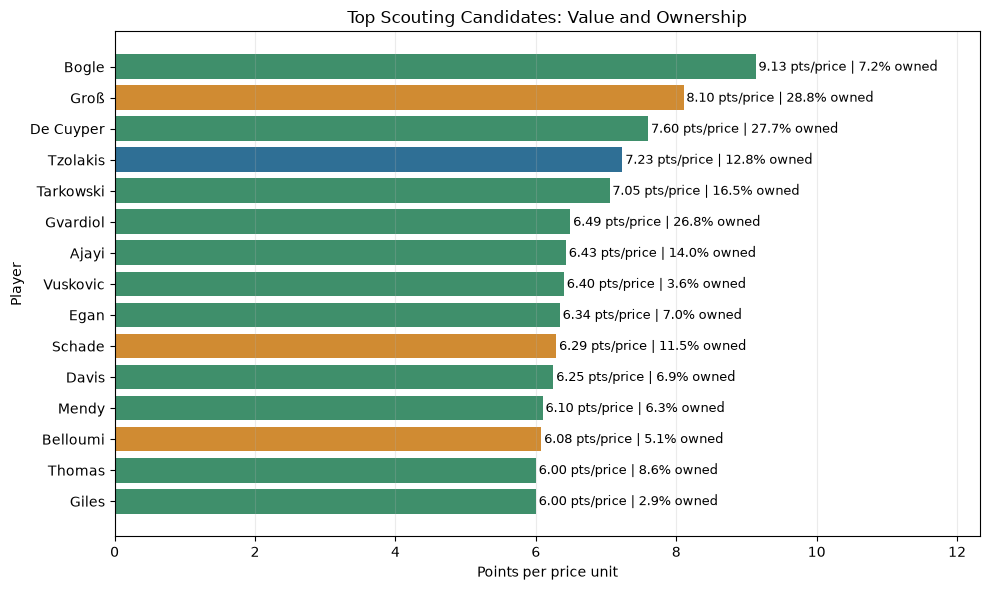

In [14]:
value_plot = (
    shortlist[["name", "position", "points_per_price", "ownership_pct"]]
    .dropna(subset=["points_per_price"])
    .sort_values("points_per_price")
    .tail(15)
)

if value_plot.empty:
    print("No players are available for the value chart.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    bar_colors = [position_colors.get(position, "#666666") for position in value_plot["position"]]
    ax.barh(value_plot["name"], value_plot["points_per_price"], color=bar_colors)
    for index, (_, player) in enumerate(value_plot.iterrows()):
        ax.text(
            player["points_per_price"] + 0.04,
            index,
            f'{player["points_per_price"]:.2f} pts/price | {player["ownership_pct"]:.1f}% owned',
            va="center",
            fontsize=9,
        )
    ax.set_title("Top Scouting Candidates: Value and Ownership")
    ax.set_xlabel("Points per price unit")
    ax.set_ylabel("Player")
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlim(0, value_plot["points_per_price"].max() * 1.35)
    plt.tight_layout()
    plt.show()

### 7.4 Upcoming fixture difficulty

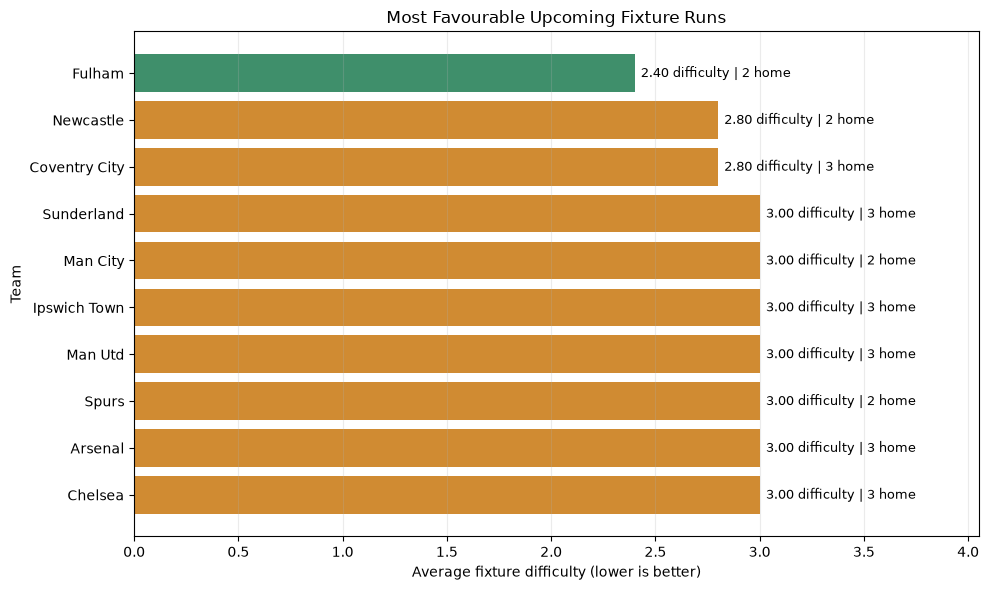

In [15]:
if fixture_summary.empty:
    print("No fixture difficulty chart available for the selected window.")
else:
    fixture_plot = fixture_summary.nsmallest(10, "average_difficulty").sort_values(
        "average_difficulty", ascending=False
    )
    fixture_colors = [
        "#3f8f6b" if difficulty <= 2.67 else "#d08b32" if difficulty <= 3.33 else "#b84a5a"
        for difficulty in fixture_plot["average_difficulty"]
    ]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fixture_plot["team_name"], fixture_plot["average_difficulty"], color=fixture_colors)
    for index, (_, team_row) in enumerate(fixture_plot.iterrows()):
        ax.text(
            team_row["average_difficulty"] + 0.03,
            index,
            f'{team_row["average_difficulty"]:.2f} difficulty | {int(team_row["home_fixtures"])} home',
            va="center",
            fontsize=9,
        )
    ax.set_title("Most Favourable Upcoming Fixture Runs")
    ax.set_xlabel("Average fixture difficulty (lower is better)")
    ax.set_ylabel("Team")
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlim(0, fixture_plot["average_difficulty"].max() * 1.35)
    plt.tight_layout()
    plt.show()

### 7.5 Average performance by position

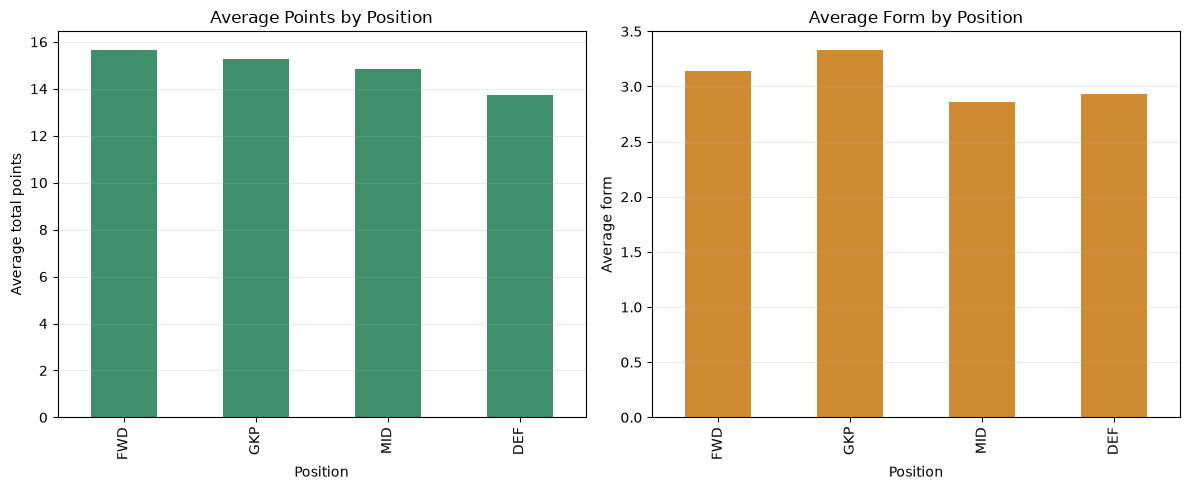

In [16]:
position_plot = (
    eligible_df.groupby("position", as_index=False)
    .agg(
        average_points=("total_points", "mean"),
        average_price=("price", "mean"),
        average_form=("form", "mean"),
    )
    .sort_values("average_points", ascending=False)
)

if position_plot.empty:
    print("No players meet the minutes threshold for a position comparison.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    position_plot.plot.bar(
        x="position", y="average_points", ax=axes[0], color="#3f8f6b", legend=False
    )
    position_plot.plot.bar(
        x="position", y="average_form", ax=axes[1], color="#d08b32", legend=False
    )
    axes[0].set_title("Average Points by Position")
    axes[0].set_xlabel("Position")
    axes[0].set_ylabel("Average total points")
    axes[1].set_title("Average Form by Position")
    axes[1].set_xlabel("Position")
    axes[1].set_ylabel("Average form")
    for axis in axes:
        axis.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Generated Scouting Notes

This cell summarizes the current API snapshot, so its names and figures stay in sync with the tables above. Treat the leaders as prompts for review, especially when minutes are limited.

In [17]:
print(f"Data snapshot: {len(players_df)} players; {len(eligible_df)} meet the {MIN_MINUTES}-minute threshold.")

if not form_view.empty:
    leader = form_view.iloc[0]
    print(
        f"Form leader: {leader['name']} ({leader['team']}) - "
        f"{leader['form']:.1f} form, {int(leader['minutes'])} minutes, "
        f"{leader['total_points']} points."
    )

if not per90_view.empty:
    leader = per90_view.iloc[0]
    print(
        f"Points-per-90 leader: {leader['name']} ({leader['team']}) - "
        f"{leader['points_per_90']:.2f} points per 90 across "
        f"{int(leader['minutes'])} minutes."
    )

if not attackers.empty:
    leader = attackers.iloc[0]
    print(
        f"Forward threat leader: {leader['name']} ({leader['team']}) - "
        f"{leader['goal_threat']:.2f} combined goals and xG."
    )

value_candidates = scouting_view.dropna(subset=["points_per_price"]).sort_values(
    "points_per_price", ascending=False
)
if not value_candidates.empty:
    leader = value_candidates.iloc[0]
    print(
        f"Value leader: {leader['name']} ({leader['team']}) - "
        f"{leader['points_per_price']:.2f} points per price unit, "
        f"{leader['ownership_pct']:.1f}% ownership."
    )

if not fixture_summary.empty:
    leader = fixture_summary.iloc[0]
    print(
        f"Easiest fixture schedule in the window: {leader['team_name']} - "
        f"{leader['average_difficulty']:.2f} average difficulty across "
        f"{int(leader['fixtures'])} fixtures."
    )

print("Use minutes, availability, underlying involvement, price, and fixtures together; no single metric guarantees future points.")

Data snapshot: 667 players; 296 meet the 90-minute threshold.
Form leader: Bogle (Leeds) - 11.3 form, 365 minutes, 42 points.
Points-per-90 leader: Manzambi (Aston Villa) - 12.86 points per 90 across 98 minutes.
Forward threat leader: Haaland (Man City) - 9.42 combined goals and xG.
Value leader: Bogle (Leeds) - 9.13 points per price unit, 7.2% ownership.
Easiest fixture schedule in the window: Fulham - 2.40 average difficulty across 5 fixtures.
Use minutes, availability, underlying involvement, price, and fixtures together; no single metric guarantees future points.
